# TV Show / Movie Genre Prediction — End-to-End Walkthrough


In [1]:
import sys
sys.path.append("src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Load the data

In [2]:
from data_loader import load_data

# Local path to the dataset on this machine. If you move the project,
# update this (or point it at the relative data/tv-shows.csv also
# included in this repo).
DATA_PATH = "/Users/sunnsinha/Downloads/TV Genere Prediction/Data/tv-shows.xlsx"

df = load_data(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (9338, 13)


,id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,platform
0,1,Movie,ChuChuTV Surprise Eggs Learning Videos (English),NaN,NaN,NaN,2019-10-18 00:00:00,2019,TV-Y,61 min,Children & Family Movies,From colors and letters to animals of all kind...,Netflix
1,2,Movie,The Journey Is the Destination,Bronwen Hughes,"Ben Schnetzer, Kelly Macdonald, Sam Hazeldine,...",United States,2017-11-07 00:00:00,2016,R,123 min,Dramas,Spirited 22-year-old activist and photojournal...,Netflix
2,3,TV Show,Champions,NaN,"Anders Holm, Fortune Feimster, Andy Favreau, J...",United States,2021-06-19 00:00:00,2018,TV-14,1 Season,TV Comedies,"Years after getting his girlfriend pregnant, w...",Netflix
3,4,TV Show,The Returned,NaN,"Anne Cosigny, Fr√©d√©ric Pierrot, Clotilde Hes...",France,2019-02-17 00:00:00,2015,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Horror",On returning home and finding they're believed...,Netflix
4,5,Movie,Super Bheem Bana Vajraveer,Sumit Das,"Sonal Kaushal, Rupa Bhimani, Julie Tejwani, Sa...",India,2019-06-18 00:00:00,2018,TV-Y7,63 min,Children & Family Movies,"Hoping to find a magical root, a monster has c...",Netflix


## 2. Exploratory Data Analysis

Basic checks: missing values, how the two platforms are represented, and
what the genre labels actually look like.

In [3]:
df.isna().sum().sort_values(ascending=False)

director        2855
country          962
cast             938
date_added        13
rating             7
duration           3
id                 0
type               0
title              0
release_year       0
listed_in          0
description        0
platform           0
dtype: int64

In [4]:
print(df["platform"].value_counts())
print()
print(df["type"].value_counts())

platform
Netflix    7926
Disney     1412
Name: count, dtype: int64

type
Movie      6528
TV Show    2810
Name: count, dtype: int64


In [5]:
primary_genre_raw = df["listed_in"].apply(lambda x: str(x).split(",")[0].strip())
primary_genre_raw.value_counts().head(15)

listed_in
Dramas                      1436
Comedies                    1088
Action & Adventure           772
Documentaries                754
International TV Shows       688
Children & Family Movies     530
Action-Adventure             432
Crime TV Shows               366
Kids' TV                     339
Animation                    315
Stand-Up Comedy              307
Horror Movies                250
Docuseries                   238
British TV Shows             235
Comedy                       188
Name: count, dtype: int64

**Data quality finding:** Netflix and Disney+ label the same genre
differently — e.g. `Action & Adventure` (Netflix) vs `Action-Adventure`
(Disney+), `Comedies` vs `Comedy`, `Documentaries` vs `Documentary`. Left
alone, this would artificially split one genre into two separate classes.
`src/preprocess.py` normalizes these (see `GENRE_SYNONYMS`) before the
target is built below.

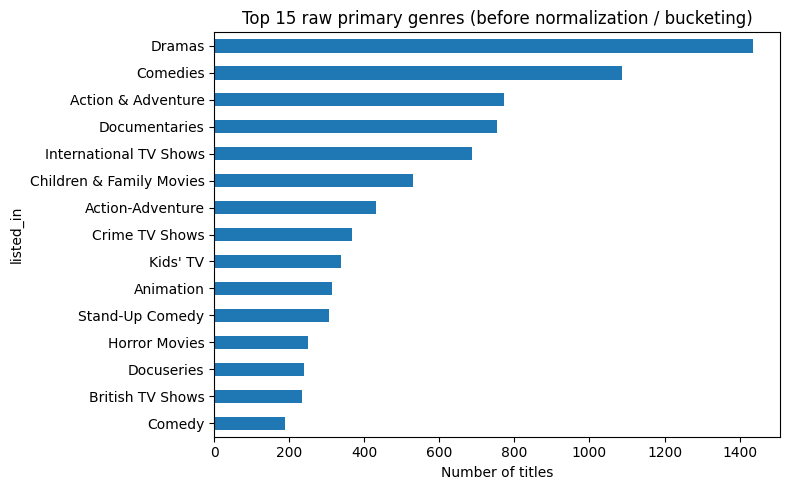

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
primary_genre_raw.value_counts().head(15).plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Number of titles")
ax.set_title("Top 15 raw primary genres (before normalization / bucketing)")
plt.tight_layout()
plt.show()

## 3. Feature engineering & target construction

Split into train/test *before* any frequency-based decisions (which
genres/countries count as "top 10") are made, so those decisions only
ever see training data.

In [7]:
from sklearn.model_selection import train_test_split
from preprocess import prepare_dataset, build_preprocessor

df_train_raw, df_test_raw = train_test_split(df, test_size=0.2, random_state=42)
print("Train rows:", len(df_train_raw), " | Test rows:", len(df_test_raw))

Train rows: 7470  | Test rows: 1868


In [8]:
X_train, y_train, allowed_countries, allowed_genres = prepare_dataset(df_train_raw)

print("Genre classes (top 10 + Other):")
print(sorted(allowed_genres))
print()
print("Feature columns:", list(X_train.columns))
X_train.head()

Genre classes (top 10 + Other):
['Action & Adventure', 'Animation', 'Children & Family Movies', 'Comedies', 'Crime TV Shows', 'Documentaries', 'Dramas', 'International TV Shows', "Kids' TV", 'Stand-Up Comedy']

Feature columns: ['type', 'platform', 'rating', 'country_clean', 'release_year', 'duration_value', 'cast_count', 'year_added', 'has_director', 'description']


,type,platform,rating,country_clean,release_year,duration_value,cast_count,year_added,has_director,description
5654,Movie,Netflix,PG,Unknown,1990,94.0,11,NaN,1,"After exposure to a strange, glowing ooze, fou..."
7285,Movie,Netflix,R,United States,2015,90.0,7,NaN,1,A New Orleans politician finds his idealistic ...
3332,Movie,Netflix,TV-MA,Other,2019,149.0,8,NaN,1,"Mentored by an enigmatic tycoon, an ambitious ..."
528,Movie,Netflix,TV-14,India,2008,131.0,9,NaN,1,An educated man assists the illiterate residen...
1233,TV Show,Netflix,TV-MA,United Kingdom,2020,9.0,17,NaN,1,This period drama set in impoverished East Lon...


In [9]:
y_train.value_counts()

primary_genre
Other                       1419
Dramas                      1235
Comedies                    1103
Action & Adventure           991
Documentaries                654
International TV Shows       553
Children & Family Movies     435
Crime TV Shows               295
Stand-Up Comedy              278
Kids' TV                     264
Animation                    243
Name: count, dtype: int64

In [10]:
# Reuse the exact same "top 10" countries/genres learned from train on the test split
X_test, y_test, _, _ = prepare_dataset(df_test_raw, allowed_countries=allowed_countries, allowed_genres=allowed_genres)
print("X_test shape:", X_test.shape)

X_test shape: (1868, 10)


## 4. Preprocessing pipeline

One-hot encoding for categorical columns, median-impute + scale for
numeric columns, TF-IDF (300 terms) for the description text.

In [11]:
preprocessor = build_preprocessor()
X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

print("Transformed train shape:", X_train_t.shape)
print("Transformed test shape :", X_test_t.shape)

Transformed train shape: (7470, 335)
Transformed test shape : (1868, 335)


## 5. Model training

Two traditional ML models, both trained on the same features.

In [12]:
from model import get_model

logreg = get_model("logistic_regression", seed=42)
logreg.fit(X_train_t, y_train)
print("Logistic Regression train accuracy:", round(logreg.score(X_train_t, y_train), 3))

Logistic Regression train accuracy: 0.659


In [13]:
rf = get_model("random_forest", seed=42)
rf.fit(X_train_t, y_train)
print("Random Forest train accuracy:", round(rf.score(X_train_t, y_train), 3))

Random Forest train accuracy: 0.8


## 6. Evaluation on the held-out test set

In [14]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def summarize(name, model):
    y_pred = model.predict(X_test_t)
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.3f}  |  Macro F1: {macro_f1:.3f}  |  Weighted F1: {weighted_f1:.3f}")
    print()
    print(classification_report(y_test, y_pred, zero_division=0))
    return y_pred

y_pred_logreg = summarize("Logistic Regression", logreg)

=== Logistic Regression ===
Accuracy: 0.595  |  Macro F1: 0.644  |  Weighted F1: 0.583

                          precision    recall  f1-score   support

      Action & Adventure       0.55      0.51      0.53       249
               Animation       0.50      0.82      0.62        72
Children & Family Movies       0.72      0.91      0.80        95
                Comedies       0.48      0.39      0.43       280
          Crime TV Shows       0.47      0.72      0.57        74
           Documentaries       0.72      0.87      0.78       163
                  Dramas       0.46      0.50      0.48       288
  International TV Shows       0.72      0.84      0.77       135
                Kids' TV       0.78      0.95      0.86        78
                   Other       0.71      0.40      0.52       373
         Stand-Up Comedy       0.62      0.87      0.73        61

                accuracy                           0.59      1868
               macro avg       0.61      0.71      0

In [15]:
y_pred_rf = summarize("Random Forest", rf)

=== Random Forest ===
Accuracy: 0.603  |  Macro F1: 0.653  |  Weighted F1: 0.587

                          precision    recall  f1-score   support

      Action & Adventure       0.52      0.49      0.51       249
               Animation       0.65      0.79      0.71        72
Children & Family Movies       0.65      0.87      0.74        95
                Comedies       0.58      0.24      0.34       280
          Crime TV Shows       0.44      0.65      0.53        74
           Documentaries       0.80      0.88      0.84       163
                  Dramas       0.42      0.68      0.52       288
  International TV Shows       0.68      0.90      0.77       135
                Kids' TV       0.79      0.94      0.86        78
                   Other       0.77      0.44      0.56       373
         Stand-Up Comedy       0.77      0.84      0.80        61

                accuracy                           0.60      1868
               macro avg       0.64      0.70      0.65   

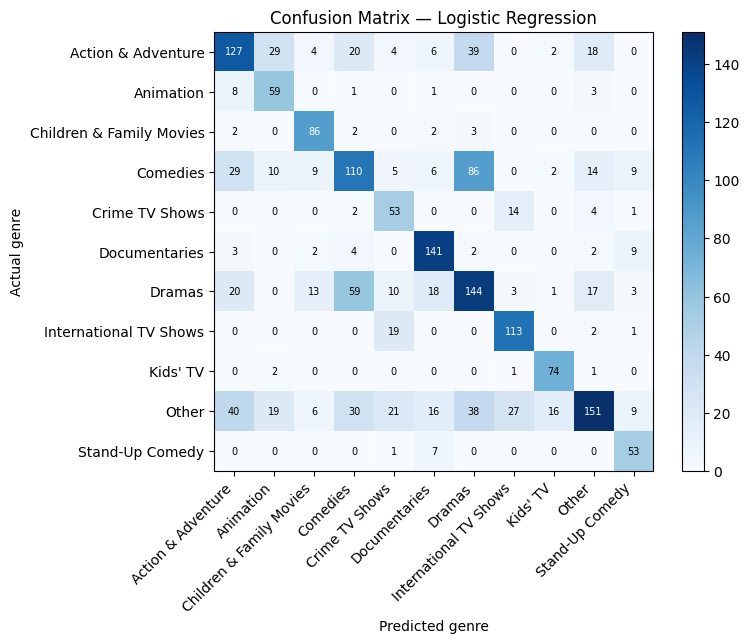

In [16]:
def plot_confusion(y_true, y_pred, title):
    labels = sorted(y_true.unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(8, 6.5))
    im = ax.imshow(cm, cmap="Blues")
    fig.colorbar(im, ax=ax)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right"); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted genre"); ax.set_ylabel("Actual genre")
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=7)
    plt.tight_layout()
    plt.show()

plot_confusion(y_test, y_pred_logreg, "Confusion Matrix — Logistic Regression")

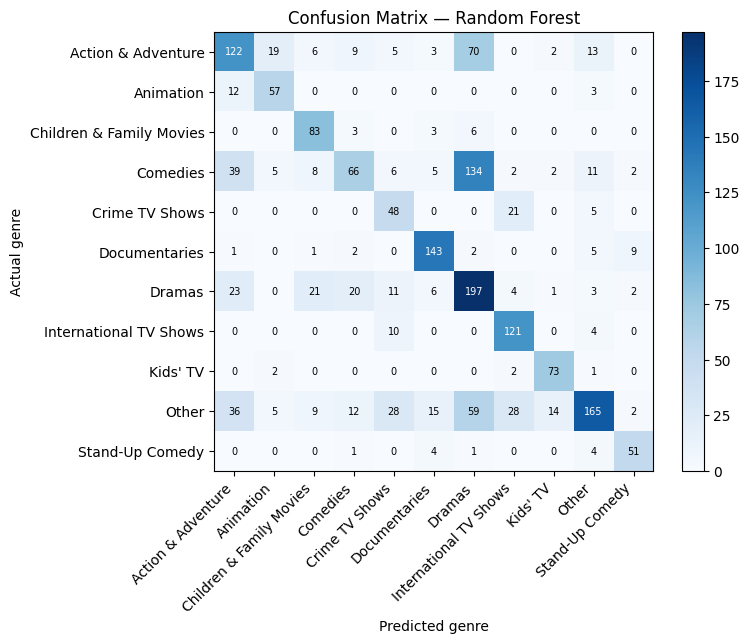

In [17]:
plot_confusion(y_test, y_pred_rf, "Confusion Matrix — Random Forest")

## 7. Explainability

Feature importance is read directly from each model's built-in
attributes: `feature_importances_` for Random Forest, `coef_` for
Logistic Regression.

In [18]:
from preprocess import CATEGORICAL_FEATURES, NUMERIC_FEATURES

cat_names = list(preprocessor.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(CATEGORICAL_FEATURES))
num_names = list(NUMERIC_FEATURES)
text_names = list(preprocessor.named_transformers_["text"].named_steps["tfidf"].get_feature_names_out())
feature_names = cat_names + num_names + text_names
print("Total features:", len(feature_names))

Total features: 335


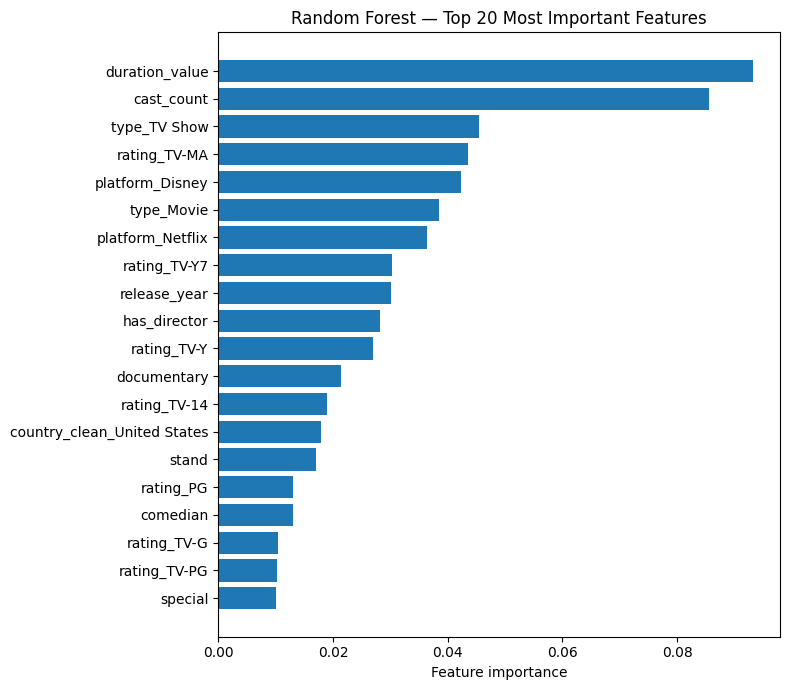

In [19]:
importances = rf.feature_importances_
top_idx = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh([feature_names[i] for i in top_idx][::-1], importances[top_idx][::-1])
ax.set_xlabel("Feature importance")
ax.set_title("Random Forest — Top 20 Most Important Features")
plt.tight_layout()
plt.show()

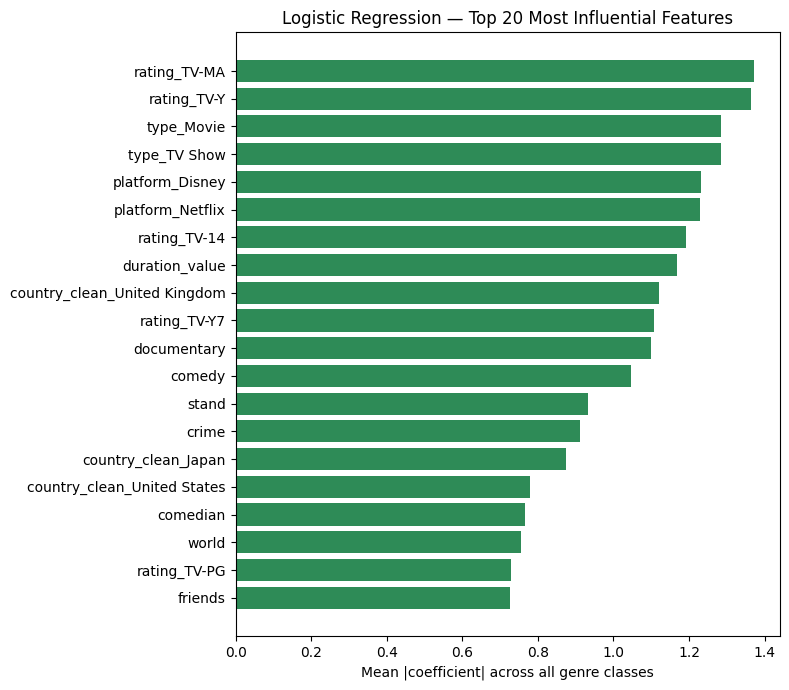

In [20]:
mean_abs_coef = np.mean(np.abs(logreg.coef_), axis=0)
top_idx = np.argsort(mean_abs_coef)[::-1][:20]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh([feature_names[i] for i in top_idx][::-1], mean_abs_coef[top_idx][::-1], color="seagreen")
ax.set_xlabel("Mean |coefficient| across all genre classes")
ax.set_title("Logistic Regression — Top 20 Most Influential Features")
plt.tight_layout()
plt.show()

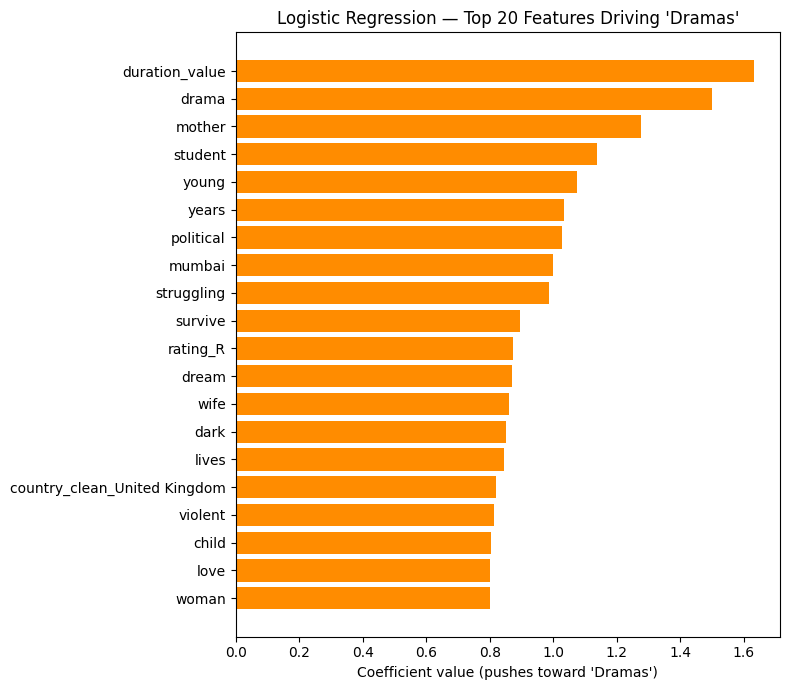

In [21]:
class_label = "Dramas"
class_idx = list(logreg.classes_).index(class_label)
coefs = logreg.coef_[class_idx]
top_idx = np.argsort(coefs)[::-1][:20]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh([feature_names[i] for i in top_idx][::-1], coefs[top_idx][::-1], color="darkorange")
ax.set_xlabel(f"Coefficient value (pushes toward '{class_label}')")
ax.set_title(f"Logistic Regression — Top 20 Features Driving '{class_label}'")
plt.tight_layout()
plt.show()

## 8. Recommendation

Random Forest is the recommended model: slightly higher accuracy (0.603
vs 0.595) and macro F1 (0.653 vs 0.644), meaning it performs a bit better
across the smaller, less frequent genres too, not just the largest ones.

Logistic Regression remains a strong baseline — it trains faster, its
coefficients give direct interpretability, and its accuracy is close
enough to Random Forest to be a reasonable, more transparent alternative.

**Main limitation:** genre is not fully determined by this metadata —
many titles could plausibly belong to more than one genre (which is
exactly why `listed_in` is multi-label in the source data), so a
meaningful share of "errors" are the model picking a different,
also-reasonable genre. A natural next step would be to treat this as
multi-label classification instead of single-label.